# Computing $\mu^{\mathrm{ex}}$ with non-stationary Gaussian processes

The Gaussian-process integration step of the extended S0 method, on the paracetamol /
water / ethanol system.

| you need | for |
|---|---|
| `Paracetamo-Water-Ethanol/S0_paracetamol_water_ethanol_303K.csv` | the 262 measured $S(0)$ compositions |
| [`gpr_grad`](https://github.com/ChengUCB/GPR_grad) | kernels and the gradient-enhanced GP |
| [`szero`](https://github.com/ChengUCB/S0_multi) | the Kirkwood–Buff inversion, $S(0) \rightarrow$ derivatives |

Every number is in kJ/mol, including the hyperparameters, which the paper quotes in eV.
Runs in well under a minute.

In [10]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

def package_root(pkg, env_var, repo, *names):
    """Directory containing `pkg`: $env_var, else a sibling or subdirectory by name."""
    import os
    tried = [Path(os.environ[env_var])] if os.environ.get(env_var) else []
    tried += [base / n for base in (Path("."), Path("..")) for n in names]
    for c in tried:
        if (c / pkg).is_dir():
            return str(c.resolve())
    raise ModuleNotFoundError(
        f"cannot find the '{pkg}' package. Clone {repo} next to this notebook, or set "
        f"{env_var} to the directory containing '{pkg}'. Looked in: "
        + ", ".join(str(c) for c in tried))


sys.path[:0] = [package_root("gpr_grad", "GPR_GRAD_DIR",
                             "https://github.com/ChengUCB/GPR_grad",
                             "GPR_grad", "GPR_grad-test_non-stationary"),
                package_root("szero", "SZERO_DIR",
                             "https://github.com/ChengUCB/S0_multi",
                             "S0_multi", "S0_multi-main")]

from gpr_grad import DirectionalGradientGP, GibbsKernelFunction, InputWarpedKernelFunction
from szero import prepare_gp_gradient_data

torch.set_default_dtype(torch.float64)   # the kernel matrices are ill-conditioned in float32

KBT = 2.520529            # kJ/mol, at 303.15 K
SIGMA_PRIOR = 96.485332   # kJ/mol
SIGMA_G = 0.289456        # kJ/mol
AMPLITUDE = SIGMA_PRIOR ** 2
THETA = torch.tensor([0.12, 0.13])

ANCHOR_X = {"water": (0.00840336, 0.0), "ethanol": (0.01351351, 0.98648649)}
ANCHOR_Y = {"water": -22.989850, "ethanol": -66.358848}

for name in ANCHOR_X:
    print(f"anchor {name:8s} mu_ex = {ANCHOR_Y[name]:9.3f} kJ/mol at {ANCHOR_X[name]}")

anchor water    mu_ex =   -22.990 kJ/mol at (0.00840336, 0.0)
anchor ethanol  mu_ex =   -66.359 kJ/mol at (0.01351351, 0.98648649)


## 1. From $S(0)$ to derivative 

`szero.prepare_gp_gradient_data` does the Kirkwood–Buff inversion — six partial $S(0)$
per composition in, $\partial\mu^{\mathrm{ex}}_{\mathrm{para}}/\partial\tilde{x}$ out, in
the independent coordinates $\tilde{\mathbf{x}} = (x_{\mathrm{para}}, x_{\mathrm{eth}})$.
Passing `kb_t` in kJ/mol is what makes the derivatives come out in kJ/mol.

Derivatives alone fix $\mu^{\mathrm{ex}}$ only up to a constant, so at least one value
observation is needed. There are two, from independent FEP/TI calculations at opposite
ends of the solvent range — which is what makes the model testable in section 4.

In the ternary interior the $3\times3$ $S(0)$ inverts and both partial derivatives come
out. On a binary edge one species is absent, the matrix is singular, and only the
derivative **along** the edge survives, from the $2\times2$ inversion.

In [11]:
df = pd.read_csv(Path("Paracetamo-Water-Ethanol") / "S0_paracetamol_water_ethanol_303K.csv")

X_COL = {"Para": "x_para", "Water": "x_water", "EtOH": "x_ethanol"}
S_COL = {"ParaPara": "S0_NN", "WaterWater": "S0_OO", "EtOHEtOH": "S0_CC",
         "ParaWater": "S0_NO", "ParaEtOH": "S0_NC", "WaterEtOH": "S0_OC"}


def gradient_observations(df):
    """Point, value and direction of every derivative observation, in (x_para, x_ethanol)."""
    segments = (
        ("ternary interior",  ["Para", "Water", "EtOH"], ["Para", "EtOH"],
         [(1.0, 0.0), (0.0, 1.0)], (df.x_water > 1e-9) & (df.x_ethanol > 1e-9)),
        ("pure-water edge",   ["Para", "Water"], ["Para"], [(1.0, 0.0)], df.x_ethanol <= 1e-9),
        ("pure-ethanol edge", ["Para", "EtOH"],  ["Para"], [(1.0, -1.0)], df.x_water <= 1e-9),
    )
    parts = {}
    for label, comps, indep, tangents, mask in segments:
        sub = df[mask].reset_index(drop=True)
        cmap = {f"x_{c}": X_COL[c] for c in comps}
        cmap.update({f"S_{a}{b}": S_COL[a + b]
                     for i, a in enumerate(comps) for b in comps[i:]})
        _, G, _ = prepare_gp_gradient_data(
            sub, independent_components=indep, column_map=cmap, components=comps,
            species="Para", excess=True, kb_t=KBT, as_torch=False)
        X = sub[["x_para", "x_ethanol"]].to_numpy(float)
        parts[label] = (np.repeat(X, len(tangents), axis=0),
                        np.asarray(G, float).reshape(-1),
                        np.tile(np.asarray(tangents, float), (len(sub), 1)))
    return parts


parts = gradient_observations(df)
X_g = torch.tensor(np.vstack([p[0] for p in parts.values()]))
G_g = torch.tensor(np.concatenate([p[1] for p in parts.values()]))
dirs = torch.tensor(np.vstack([p[2] for p in parts.values()]))

print(f"{len(df)} compositions in the CSV")
for label, (X, G, d) in parts.items():
    print(f"  {label:18s} {len(np.unique(X, axis=0)):>4d} compositions -> {len(G):>4d} observations"
          f"   along {sorted({tuple(int(v) for v in r) for r in d})}")
print(f"\nX_g {tuple(X_g.shape)}   G_g {tuple(G_g.shape)} [kJ/mol]   dirs {tuple(dirs.shape)}")


262 compositions in the CSV
  ternary interior    228 compositions ->  456 observations   along [(0, 1), (1, 0)]
  pure-water edge      12 compositions ->   12 observations   along [(1, 0)]
  pure-ethanol edge    22 compositions ->   22 observations   along [(1, -1)]

X_g (490, 2)   G_g (490,) [kJ/mol]   dirs (490, 2)


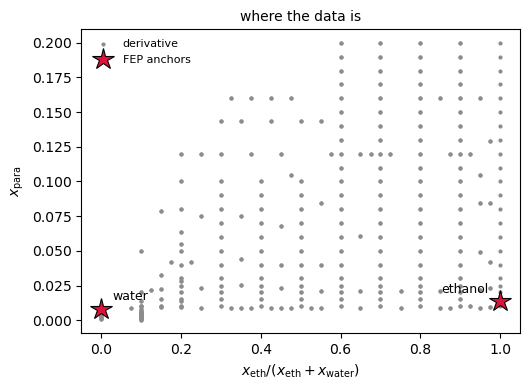

In [12]:
fig, ax = plt.subplots(figsize=(5.4, 4.0))
x_eth_solvent = (X_g[:, 1] / (1.0 - X_g[:, 0])).numpy()
ax.scatter(x_eth_solvent, X_g[:, 0], s=9, c="0.55", lw=0, label="derivative")
for name, (xp, xe) in ANCHOR_X.items():
    sf = xe / (1.0 - xp)
    ax.plot(sf, xp, "*", ms=16, mec="k", mfc="crimson", mew=0.8,
            label="FEP anchors" if name == "water" else None)
    ax.annotate(name, (sf, xp), textcoords="offset points", fontsize=9,
                xytext=(8, 6) if sf < 0.5 else (-8, 6), ha="left" if sf < 0.5 else "right")
ax.set_xlabel(r"$x_\mathrm{eth}/(x_\mathrm{eth}+x_\mathrm{water})$")
ax.set_ylabel(r"$x_\mathrm{para}$")
ax.set_title("where the data is", fontsize=10)
ax.legend(fontsize=8, frameon=False)
fig.tight_layout()

Towards pure water the accessible $x_{\mathrm{para}}$ collapses below $0.007$; in
ethanol-rich mixtures it reaches $0.2$. The GP has to carry the pure-water anchor across
the sparsest part of the domain to reach the ethanol side, and that transport is what the
kernel choice decides.

## 2. Why an edge observation is not a partial derivative

`GradientGP` stores each gradient observation as a `[point index, coordinate index]`
pair: **one integer**, selecting one axis. A general direction needs $D$ floats, so the
two are not interchangeable — and one of the three observation types above is not
axis-aligned.

Walk along the water-free edge with parameter $s$, where
$(x_{\mathrm{para}}, x_{\mathrm{eth}}) = (s,\,1-s)$. The chain rule gives what the
$2\times2$ inversion returns:

$$g \;=\; \frac{\partial\mu^{\mathrm{ex}}}{\partial x_{\mathrm{para}}}\cdot(+1)
\;+\; \frac{\partial\mu^{\mathrm{ex}}}{\partial x_{\mathrm{eth}}}\cdot(-1)
\;=\; \frac{\partial\mu^{\mathrm{ex}}}{\partial x_{\mathrm{para}}}
- \frac{\partial\mu^{\mathrm{ex}}}{\partial x_{\mathrm{eth}}}.$$

One number, the *difference* of two partials — and the two partials are not separately
available, because the $3\times3$ $S(0)$ is singular on the edge. The cell below shows
how far that difference is from either partial, at interior compositions close enough to
the edge that both are still measurable.

The pure-water edge escapes the problem for a reason worth naming: there the path is
$(s, 0)$, so $\mathrm{d}x_{\mathrm{eth}}/\mathrm{d}s = 0$, the second term vanishes, and
$g$ *is* $\partial\mu^{\mathrm{ex}}/\partial x_{\mathrm{para}}$. Nothing about edges is
special; what matters is whether the measurement direction lines up with a coordinate
axis.

In [13]:
X_int, G_int, d_int = parts["ternary interior"]
near = {}
for x, g, d in zip(X_int, G_int, d_int):
    r = x[1] / (1.0 - x[0])
    if r > 0.9:
        near.setdefault(tuple(x), {})[tuple(d)] = g

print("interior compositions near the water-free edge -- both partials still measurable")
print(f"{'x_para':>8} {'x_eth':>8} | {'d/dx_para':>10} {'d/dx_eth':>10} | {'difference':>11}")
for x in sorted(near)[:4]:
    v = near[x]
    if (1.0, 0.0) in v and (0.0, 1.0) in v:
        a, b = v[(1.0, 0.0)], v[(0.0, 1.0)]
        print(f"{x[0]:8.4f} {x[1]:8.4f} | {a:10.2f} {b:10.2f} | {a - b:11.2f}")

print("\nON the edge, this single number is all the inversion can give:")
X_e, G_e, _ = parts["pure-ethanol edge"]
for x, g in list(zip(X_e, G_e))[:4]:
    print(f"{x[0]:8.4f} {x[1]:8.4f} | {'(unavailable)':>10} {'(unavailable)':>10} | {g:11.2f}")

interior compositions near the water-free edge -- both partials still measurable
  x_para    x_eth |  d/dx_para   d/dx_eth |  difference
  0.0087   0.9421 |      67.42      -3.03 |       70.45
  0.0095   0.9659 |      16.77       6.34 |       10.43
  0.0103   0.9153 |      47.87      -3.73 |       51.59
  0.0219   0.9296 |      -1.04      -2.90 |        1.86

ON the edge, this single number is all the inversion can give:
  0.0103   0.9897 | (unavailable) (unavailable) |       59.54
  0.0150   0.9850 | (unavailable) (unavailable) |       25.55
  0.0204   0.9796 | (unavailable) (unavailable) |        7.61
  0.0250   0.9750 | (unavailable) (unavailable) |       16.08


Reporting that number as `[point, 0]` would assert it is
$\partial\mu^{\mathrm{ex}}/\partial x_{\mathrm{para}}$; as `[point, 1]`, that it is
$\partial\mu^{\mathrm{ex}}/\partial x_{\mathrm{eth}}$. Both are wrong, and how wrong
depends on where you are: anything from a few percent, where one partial happens to
dominate, to a flipped sign.

The fix needs nothing from the kernels. A derivative is a *linear* functional, and a GP
is closed under those: the covariance of $\mathbf{d}\cdot\nabla f$ is the same
contraction applied to the kernel's axis-aligned derivative blocks,

$$\mathrm{Cov}\big(f(x_*),\,g_m\big) = \sum_a d_{ma}\,\frac{\partial k}{\partial y_a}(x_*,x_m),
\qquad
\mathrm{Cov}\big(g_n,\,g_m\big) = \sum_{ab} d_{na} d_{mb}\,
\frac{\partial^2 k}{\partial x_a \partial y_b}(x_n,x_m),$$

which is what `gpr_grad.DirectionalGradientGP` assembles. It takes one direction per
observation instead of a `grad_indices` table, works with every kernel in the package,
and reproduces `GradientGP` exactly when every direction is a basis vector.

In [14]:
def fit(kernel, sigma_g=SIGMA_G, anchors=("water", "ethanol")):
    """Fit mu_ex from all 490 derivative observations plus the chosen value anchors."""
    return DirectionalGradientGP(kernel, sigma_f=0.0, sigma_g=sigma_g,
                                 jitter=1e-8 * AMPLITUDE).fit(
        torch.tensor([ANCHOR_X[a] for a in anchors]),
        torch.tensor([ANCHOR_Y[a] for a in anchors]),
        X_g, G_g, dirs)


def mu_ex(gp, x_para, x_eth_solvent):
    """mu_ex in kJ/mol along a line of constant solute-free ethanol fraction."""
    x_para = np.atleast_1d(np.asarray(x_para, float))
    pts = torch.tensor(np.column_stack([x_para, x_eth_solvent * (1.0 - x_para)]))
    return gp.predict(pts, return_cov=False).detach().numpy()


def rbf(theta, outputscale=AMPLITUDE):
    """Stationary RBF at a given prior amplitude.

    `RBFKernelFunction` has no outputscale, and in a fixed-unit notebook the amplitude has
    to be set explicitly, so the baseline is written as the warp at alpha = 0 -- the same
    kernel, to floating-point.
    """
    return InputWarpedKernelFunction(theta, warp_alpha=torch.tensor([0.0, 0.0]),
                                     outputscale=outputscale)


# sigma_f = 0 makes the anchors hard constraints, so the fit must return them
_gp = fit(rbf(torch.tensor([0.16, 0.11])))
for name, x in ANCHOR_X.items():
    got = _gp.predict(torch.tensor([x]), return_cov=False).item()
    print(f"anchor {name:8s} target {ANCHOR_Y[name]:9.4f}   fitted {got:9.4f}   "
          f"diff {got - ANCHOR_Y[name]:+.1e} kJ/mol")

anchor water    target  -22.9899   fitted  -22.9898   diff +8.8e-05 kJ/mol
anchor ethanol  target  -66.3588   fitted  -66.3588   diff +4.3e-05 kJ/mol


## 3. Three kernels

All of them start from the same anisotropic RBF,

$$k_\mathrm{RBF}(X,X') = \exp\!\left(-\frac{\lVert X-X'\rVert^2}{2\theta^2}\right),$$

and differ in how the length scale may depend on where you are.

**(a) Stationary RBF** — one $\theta_d$ per dimension, everywhere. The baseline.

**(b) Input-warped RBF** — warp each coordinate before applying the stationary kernel,
$w_d(X_d)=(e^{\alpha_d X_d}-1)/(e^{\alpha_d}-1)$, which makes the *effective* local
length scale $\theta_d / w_d'(X_d)$. One extra parameter per warped dimension;
$\alpha_d = 0$ recovers (a) exactly.

**(c) Gibbs RBF** — make the length scale an explicit field,
$\ell_d(X)=\theta_d\,e^{\beta_{1d}X_d+\beta_{2d}X_d^2}$, under the Paciorek–Schervish
covariance, whose square-root prefactor keeps it a valid kernel for any positive
$\ell_d$. $\beta_1=\beta_2=0$ recovers (a) exactly.

**(d)** The same warp over a Matérn-5/2 base — a rougher prior. With derivative
observations use $\nu \geq 5/2$: Matérn-3/2 is not twice mean-square differentiable, so
its gradient–gradient block is not a true derivative covariance.

Only $x_{\mathrm{eth}}$ is warped: the $x_{\mathrm{para}}$ direction is short and well
sampled, and needs no help.

The stationary and input-warped RBFs share $\theta$ and $\sigma_g$ and differ only in
$\alpha$, so the pair isolates what the warp does; those are the production values, the
ones the $\mu^{\mathrm{ex}}$ surface in the paper is built from. Gibbs and Matérn have no
production setting to inherit, so each is shown at the best its own family reaches, found
by a grid search not reproduced here. Comparing every family at one borrowed setting would
say more about whose hyperparameters were used than about the kernels — but note the flip
side: those two rows are grid minima on a rugged surface, so read them as "the best this
family manages", not as recommended settings.

stationary RBF       theta_eff(0.05) = 0.1300   theta_eff(0.90) = 0.1300   ratio = 1.000
input-warped RBF     theta_eff(0.05) = 0.1376   theta_eff(0.90) = 0.1237   ratio = 1.112
Gibbs RBF            theta_eff(0.05) = 0.1421   theta_eff(0.90) = 0.1834   ratio = 0.775
warped Matern-5/2    theta_eff(0.05) = 0.1567   theta_eff(0.90) = 0.1115   ratio = 1.405


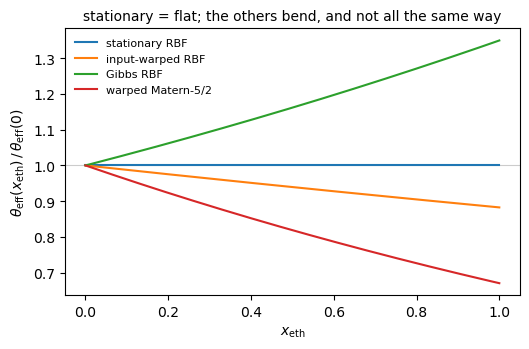

In [15]:
def warped(theta, alpha, base="rbf", **kw):
    return InputWarpedKernelFunction(theta, warp_alpha=torch.tensor([0.0, alpha]),
                                     outputscale=AMPLITUDE, base=base, **kw)


# theta, shape parameter, sigma_g [kJ/mol]
# The warped RBF is the production kernel, so it carries the values the paper reports, and
# the stationary baseline carries the same theta and sigma_g -- only alpha differs, which
# is what makes that pair a controlled comparison. Gibbs and Matern have no production
# setting to inherit, so each is shown at the best its own family reaches.
KERNELS = {
    "stationary RBF":    (rbf(torch.tensor([0.12, 0.13])), 0.10),
    "input-warped RBF":  (warped(torch.tensor([0.12, 0.13]), 0.125), 0.10),
    "Gibbs RBF":         (GibbsKernelFunction(torch.tensor([0.16, 0.14]),
                                              beta1=torch.tensor([0.0, 0.30]),
                                              outputscale=AMPLITUDE), 0.0965),
    "warped Matern-5/2": (warped(torch.tensor([0.12, 0.13]), 0.40, base="matern52"), 0.1930),
}

FITS = {name: fit(k, sg) for name, (k, sg) in KERNELS.items()}


def theta_eff_eth(kernel, x_eth):
    """Effective length scale along the ethanol axis, as a function of x_eth."""
    X = torch.tensor(np.column_stack([np.zeros_like(x_eth), x_eth]))
    return kernel.effective_theta(X)[:, 1].detach().numpy()


grid = np.linspace(0.0, 1.0, 201)
fig, ax = plt.subplots(figsize=(5.4, 3.6))
# normalised to x_eth = 0: the kernels have very different absolute theta, and what
# matters here is the *shape* of the non-stationarity, not the overall scale
for name, (kernel, _) in KERNELS.items():
    t = theta_eff_eth(kernel, grid)
    ax.plot(grid, t / t[0], label=name)
ax.axhline(1.0, color="0.8", lw=0.8, zorder=0)
ax.set_xlabel(r"$x_\mathrm{eth}$")
ax.set_ylabel(r"$\theta_\mathrm{eff}(x_\mathrm{eth}) \,/\, \theta_\mathrm{eff}(0)$")
ax.set_title("stationary = flat; the others bend, and not all the same way", fontsize=10)
ax.legend(fontsize=8, frameon=False)
fig.tight_layout()

for name, (kernel, _) in KERNELS.items():
    t = theta_eff_eth(kernel, np.array([0.05, 0.90]))
    print(f"{name:20s} theta_eff(0.05) = {t[0]:.4f}   theta_eff(0.90) = {t[1]:.4f}"
          f"   ratio = {t[0] / t[1]:.3f}")

Read the signs off the printout rather than assuming them. At
$\alpha_{\mathrm{eth}} = +0.125$ the warp **shortens** the length scale towards ethanol;
at $\beta_{1,\mathrm{eth}} = +0.30$ the Gibbs field **lengthens** it.
Positive $\alpha$ and positive $\beta_1$ bend it in opposite directions, because one acts
on the coordinate and the other directly on $\ell$.

The two are not reparametrisations of each other either. The warp changes the metric
globally — it rescales the distance between *every* pair of points — while the Gibbs
construction modulates a local scale and renormalises.

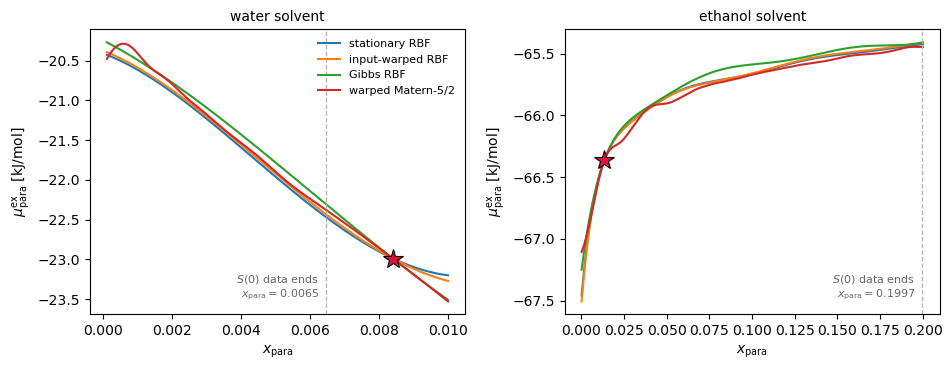

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.8))
for ax, (sf, anchor, xp_max) in zip(axes, [(0.0, "water", 0.010), (1.0, "ethanol", 0.20)]):
    xp = np.linspace(1e-4, xp_max, 160)
    for name, gp in FITS.items():
        ax.plot(xp, mu_ex(gp, xp, sf), label=name)
    ax.plot(ANCHOR_X[anchor][0], ANCHOR_Y[anchor], "*", ms=15,
            mec="k", mfc="crimson", mew=0.8, zorder=5)

    x_last = df.x_para[np.isclose(df.x_ethanol / (1.0 - df.x_para), sf, atol=1e-9)].max()
    ax.axvline(x_last, color="0.7", lw=0.9, ls="--")
    ax.annotate(f"$S(0)$ data ends\n$x_\\mathrm{{para}}={x_last:.4f}$", (x_last, 0.06),
                xycoords=("data", "axes fraction"), textcoords="offset points",
                xytext=(-5, 0), ha="right", fontsize=8, color="0.4")

    ax.set_xlabel(r"$x_\mathrm{para}$")
    ax.set_ylabel(r"$\mu^\mathrm{ex}_\mathrm{para}$ [kJ/mol]")
    ax.set_title(f"{anchor} solvent", fontsize=10)
axes[0].legend(fontsize=8, frameon=False)
fig.tight_layout()

All four kernels see identical data, so every difference above is prior, not measurement.
On the water line they agree — over that tiny $x_{\mathrm{para}}$ range there is nothing
to disagree about — and on the ethanol line they separate, but nothing in the picture says
which is right. Note too that the water anchor sits at $x_{\mathrm{para}} = 0.0084$, past
where the $S(0)$ data on that line stops: even reaching its own anchor, the GP is
extrapolating a little.

## 4. Choosing the hyperparameters: leave-one-anchor-out

The two anchors sit at opposite ends of the composition range, which gives a genuine
held-out test: **fit with one, predict the other**. That error — LOAO — is exactly what
the integration has to get right, and it is what the production hyperparameters were
selected against.

In [17]:
def loao(kernel, sigma_g=SIGMA_G):
    """Error in kJ/mol at each anchor in turn, when that anchor is held out of the fit."""
    errors = {}
    for held, kept in (("water", "ethanol"), ("ethanol", "water")):
        gp = fit(kernel, sigma_g, anchors=(kept,))
        errors[held] = gp.predict(torch.tensor([ANCHOR_X[held]]),
                                  return_cov=False).item() - ANCHOR_Y[held]
    return errors


for name, (kernel, sg) in KERNELS.items():
    e = loao(kernel, sg)
    print(f"{name:20s} held-out water {e['water']:+8.2f}   "
          f"held-out ethanol {e['ethanol']:+8.2f}   max {max(map(abs, e.values())):7.2f} kJ/mol")

stationary RBF       held-out water    +5.83   held-out ethanol    -4.76   max    5.83 kJ/mol
input-warped RBF     held-out water    +0.33   held-out ethanol    +0.31   max    0.33 kJ/mol
Gibbs RBF            held-out water    +0.19   held-out ethanol    +0.41   max    0.41 kJ/mol
warped Matern-5/2    held-out water   +38.24   held-out ethanol   +38.84   max   38.84 kJ/mol


In [18]:
rows = []
for name, (kernel, sg) in KERNELS.items():
    e = loao(kernel, sg)
    t = theta_eff_eth(kernel, np.array([0.05, 0.90]))
    rows.append({"kernel": name,
                 "sigma_g [kJ/mol]": sg,
                 "theta_eff(0.05)": round(float(t[0]), 4),
                 "theta_eff(0.90)": round(float(t[1]), 4),
                 "max |LOAO| [kJ/mol]": round(max(map(abs, e.values())), 2)})
pd.DataFrame(rows).set_index("kernel")

,sigma_g [kJ/mol],theta_eff(0.05),theta_eff(0.90),max |LOAO| [kJ/mol]
kernel,,,,
stationary RBF,0.1000,0.1300,0.1300,5.83
input-warped RBF,0.1000,0.1376,0.1237,0.33
Gibbs RBF,0.0965,0.1421,0.1834,0.41
warped Matern-5/2,0.1930,0.1567,0.1115,38.84


**Take away**
Non-stationarity is needed because the composition scale over which
   $\mu^{\mathrm{ex}}$ varies is not constant across the solvent range. Input warping and
   the Gibbs field both reduce exactly to the stationary RBF at zero, so that limit is
   always available as a check.

